In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
plt.style.use('bmh')

In [2]:
try: 
    df=pd.read_csv("AB_NYC_2019.csv")
    print("Loaded!")
except: 
     print("Error!")

Loaded!


### שלב א- ניקוי הנתונים 

In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
df['last_review'] = df['last_review'].fillna('0').astype(str)
df['reviews_per_month'] = df['reviews_per_month'].fillna('0').astype(float)

##### נציג לאילו שנים הנתונים רלוונטים

In [8]:
def check_year_of_last_review(x):
    if x == '0':
        return '0'
    else:
        return x.split('-')[0]
df['year_of_last_review'] = df['last_review'].apply(check_year_of_last_review)
df['year_of_last_review'].unique()

array(['2018', '2019', '0', '2017', '2011', '2016', '2012', '2015',
       '2013', '2014'], dtype=object)

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
year_of_last_review               0
dtype: int64

In [11]:
df.shape

(48858, 17)

In [12]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.885800e+04,4.885800e+04,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000
mean,1.902335e+07,6.763169e+07,40.728941,-73.952170,152.740309,7.012444,23.273098,1.091124,7.148369,112.801425
std,1.098289e+07,7.862389e+07,0.054528,0.046159,240.232386,20.019757,44.549898,1.597270,32.964600,131.610962
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.475980e+06,7.818669e+06,40.690090,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.969114e+07,3.079133e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915765e+07,1.074344e+08,40.763107,-73.936280,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### טיפול בערכים חריגים וניקוי הדטא

In [13]:
print(f"The number of listings with zero dollars a night: {len(df[df['price']==0])}\nThe number of listings that are not availible at all:{len(df[df['availability_365']==0])}")

The number of listings with zero dollars a night: 11
The number of listings that are not availible at all:17508


In [14]:
data1=df[df['availability_365']>0]
new_df=data1[data1['price']>0].copy()

##### נכסים עם עלות של 0 דולר לילה או נכסים עם זמינות של 0 ימים בשנה לא מייצגים את השוק האמיתי ויכולים להשפיע על הניתוח שלנו,כנראה שמדובר בנכסים לא פעילים 

In [15]:
new_df.shape

(31342, 17)

In [16]:
new_df[['price','minimum_nights','number_of_reviews','availability_365','calculated_host_listings_count','reviews_per_month']].describe()

,price,minimum_nights,number_of_reviews,availability_365,calculated_host_listings_count,reviews_per_month
count,31342.000000,31342.000000,31342.000000,31342.000000,31342.000000,31342.000000
mean,162.104397,8.307862,31.841969,175.799949,10.338970,1.509635
std,254.485555,23.175628,51.634553,126.183544,40.712884,1.781367
min,10.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,70.000000,2.000000,2.000000,55.000000,1.000000,0.170000
50%,112.000000,3.000000,10.000000,167.000000,1.000000,0.920000
75%,189.000000,5.000000,39.000000,305.000000,3.000000,2.340000
max,10000.000000,1250.000000,629.000000,365.000000,327.000000,58.500000


###### הערות: לגבי עמודת מחיר לפי סטיית התקן ניתן להסיק שטווח המחירים גדול והם פוזרים בין 10 ל10000

#### נסתכל על פריסת המחירים

<Axes: ylabel='Frequency'>

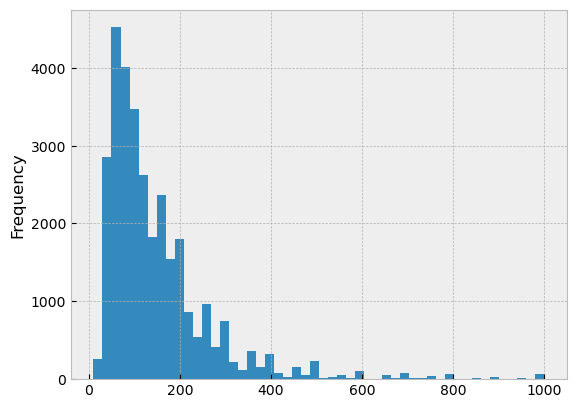

In [17]:
normal_price_range=new_df['price']<=1000
new_df[normal_price_range]['price'].plot(kind='hist',bins=50)

In [18]:
print(f"{round((new_df[new_df['price']<400].shape[0]/new_df.shape[0])*100,2) }% of the apeartments are under 400 dollars a night")

95.06% of the apeartments are under 400 dollars a night


<Axes: ylabel='Frequency'>

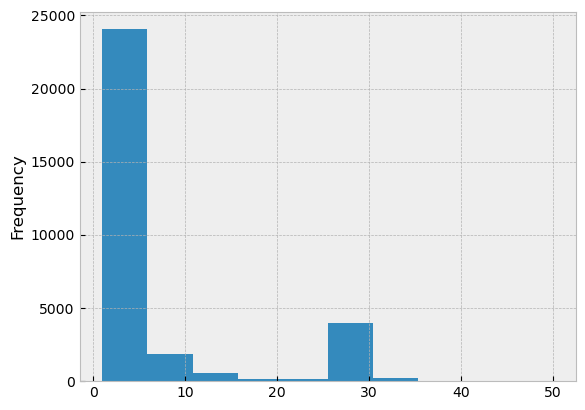

In [19]:
minimum_under_a_month=new_df['minimum_nights']<=50
new_df[minimum_under_a_month]['minimum_nights'].plot(kind='hist')

In [20]:
new_df[new_df['minimum_nights']>100]['room_type'].value_counts()

room_type
Entire home/apt    101
Private room        41
Shared room          1
Name: count, dtype: int64

#### רוב הדירות לא דורשים מינימום לילות גבוהה במיוחד, אך קיימות דירות עם מינימום לילות ארוך כנראה שמדובר בדירות שנועדו לשהייה ממושכת

<Axes: ylabel='Frequency'>

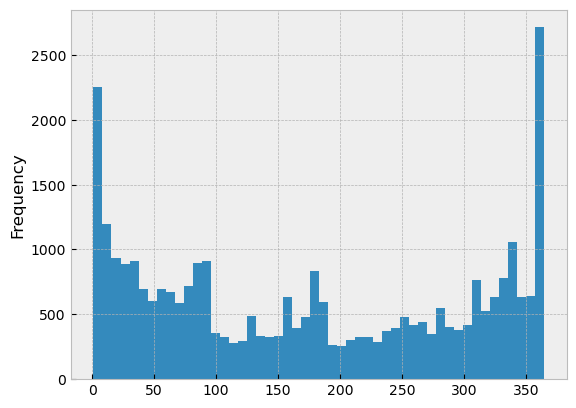

In [21]:
new_df['availability_365'].plot(kind='hist',bins=50)

In [22]:
more_then_10_month=(new_df[new_df['availability_365']>=300].shape[0]/new_df.shape[0])*100
under_a_month=(new_df[new_df['availability_365']<=30].shape[0]/new_df.shape[0])*100
print(f'{round(more_then_10_month,2)}% of the apertments are advilibal for mor then 10 month,\n{round(under_a_month,2)}% of the apartments are avalibale only for a month or less\nThe {round(100-(more_then_10_month+under_a_month),2) }% are avalibale for 1-10 month')

26.03% of the apertments are advilibal for mor then 10 month,
16.82% of the apartments are avalibale only for a month or less
The 57.15% are avalibale for 1-10 month


In [23]:
new_df[new_df['availability_365']==1]['neighbourhood'].value_counts()

neighbourhood
Williamsburg          34
Bedford-Stuyvesant    30
Harlem                24
East Village          19
Bushwick              18
                      ..
Carroll Gardens        1
Kew Gardens Hills      1
Brownsville            1
Port Morris            1
Kips Bay               1
Name: count, Length: 77, dtype: int64

<Axes: ylabel='Frequency'>

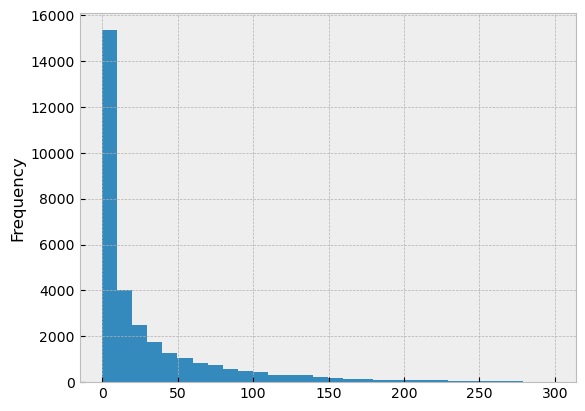

In [24]:
c1=new_df['number_of_reviews']<300
new_df[c1]['number_of_reviews'].plot(kind='hist',bins=30)

#### הצגה של מספר הביקורות הממוצע-לרוב הדירות יש פחות מ50 ביקורות

<Axes: ylabel='Frequency'>

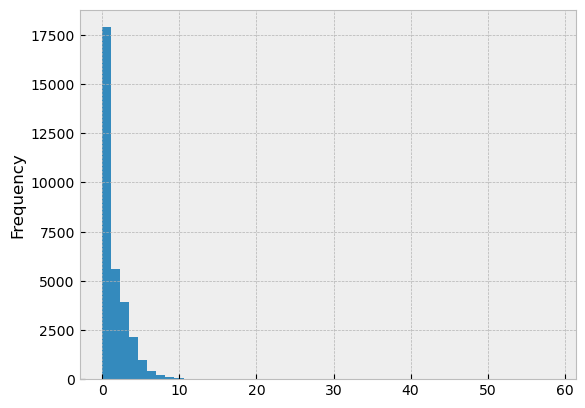

In [25]:
new_df['reviews_per_month'].plot(kind='hist',bins=50)

<Axes: title={'center': 'The most commen neighbourhood groups'}, xlabel='neighbourhood_group'>

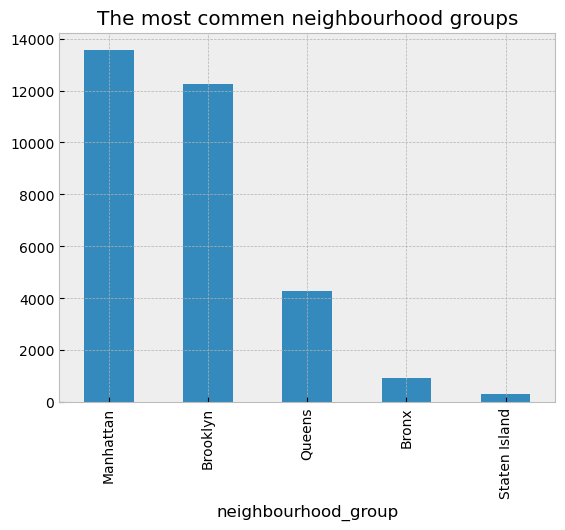

In [26]:
new_df['neighbourhood_group'].value_counts().plot(kind='bar',title='The most commen neighbourhood groups')

In [27]:
c1=new_df['neighbourhood_group']=='Manhattan'
c2=new_df['neighbourhood_group']=='Brooklyn'
print(f'{(round(new_df[c1|c2].shape[0]/new_df.shape[0]*100,2))}% of the listings are located in Manhattan or in Brooklyn')

82.33% of the listings are located in Manhattan or in Brooklyn


In [28]:
new_df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [29]:
new_df['neighbourhood'].nunique()

218

#### בדיקה של השכונות בכל איזור

<Axes: title={'center': 'Apartments by Neighbourhood (Top 10)'}, xlabel='neighbourhood'>

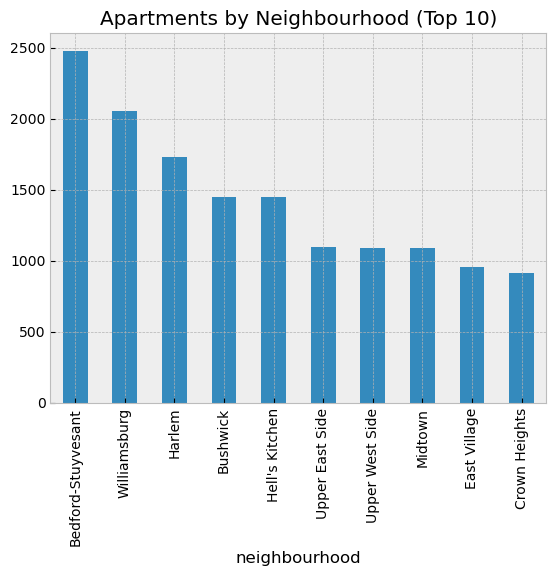

In [30]:
new_df['neighbourhood'].value_counts().head(10).plot(kind='bar',title='Apartments by Neighbourhood (Top 10)')

<Axes: title={'center': 'The most commen room types'}, xlabel='room_type', ylabel='Number_Of_Listing'>

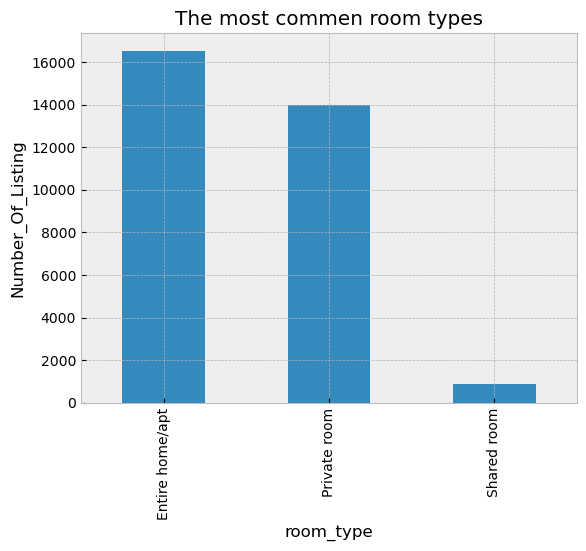

In [31]:
new_df['room_type'].value_counts().plot(kind='bar',ylabel='Number_Of_Listing',title='The most commen room types')

In [32]:
new_df['room_type'].value_counts(normalize=True)

room_type
Entire home/apt    0.527248
Private room       0.445281
Shared room        0.027471
Name: proportion, dtype: float64

#### בדיקת הקשר בין סוג החדר למחיר

<Axes: title={'center': 'Average priceing of each room type'}, xlabel='room_type'>

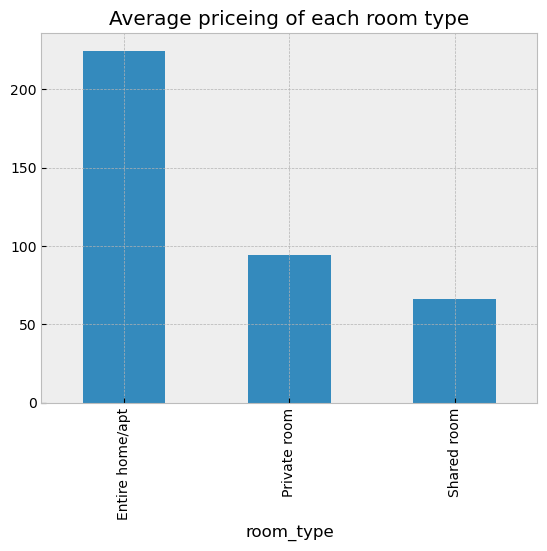

In [33]:
new_df.groupby('room_type')['price'].mean().plot(kind='bar',title='Average priceing of each room type')

In [34]:
new_df.groupby('room_type')['price'].mean()

room_type
Entire home/apt    224.637700
Private room        93.984666
Shared room         66.072009
Name: price, dtype: float64

### בדיקת הקשר בין הרובע למחיר

<Axes: title={'center': 'Average priceing by Neighburhood Group'}, xlabel='neighbourhood_group'>

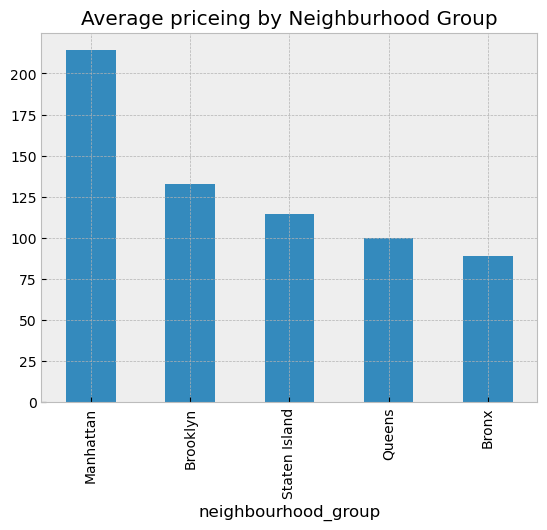

In [35]:
new_df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).plot(kind='bar',title='Average priceing by Neighburhood Group')

In [36]:
new_df.groupby('neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx             89.075741
Brooklyn         132.950686
Manhattan        214.198451
Queens           100.041424
Staten Island    114.229607
Name: price, dtype: float64

#### ברובעים קטנים הממוצע לא יציב ויכול להיות שיש הרבה נכסים צעירים

In [37]:
price_by_neighbourhood=new_df.groupby(['neighbourhood','neighbourhood_group'])['price'].describe().sort_values('mean',ascending=False)
price_by_neighbourhood

,,count,mean,std,min,25%,50%,75%,max
neighbourhood,neighbourhood_group,,,,,,,,
Fort Wadsworth,Staten Island,1.0,800.000000,NaN,800.0,800.00,800.0,800.00,800.0
Sea Gate,Brooklyn,3.0,569.666667,792.808510,99.0,112.00,125.0,805.00,1485.0
Riverdale,Bronx,8.0,567.250000,826.448642,49.0,96.75,200.0,650.00,2500.0
Tribeca,Manhattan,121.0,561.462810,992.255537,80.0,250.00,309.0,490.00,8500.0
Battery Park City,Manhattan,33.0,515.272727,1404.222923,55.0,100.00,158.0,250.00,7500.0
...,...,...,...,...,...,...,...,...,...
Soundview,Bronx,12.0,54.750000,21.320605,28.0,44.25,47.0,61.25,103.0
Port Richmond,Staten Island,5.0,48.800000,5.718391,40.0,47.00,50.0,52.00,55.0
Hunts Point,Bronx,16.0,44.625000,11.769310,35.0,36.75,40.0,48.50,70.0


##### הערה: יש שכונות שיש רק ערך אחד,נבדוק כמה נכסים יש בכל שכונה,ומי השכונות עם הכי קצת נכסים

In [38]:
new_df[new_df['neighbourhood']=='Fort Wadsworth']

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,year_of_last_review
25386,20305160,Beach House Retreat. 15 minutes from Manhattan.,1715301,Mark,Staten Island,Fort Wadsworth,40.59546,-74.06092,Entire home/apt,800,7,0,0,0.0,3,365,0


In [39]:
new_df['neighbourhood'].value_counts().describe()

count     218.000000
mean      143.770642
std       328.517649
min         1.000000
25%         8.000000
50%        26.500000
75%       110.500000
max      2478.000000
Name: count, dtype: float64

#### יש לנו 218 שכונות בממוצע יש 143 דירות בכל שכונה אך נסטיית התקן מאוד גדולה סימן שיש לנו שכונות עם הרבה מאוד דירות ושכונות עם קצת דירות

In [40]:
neighbourhood_counts=new_df['neighbourhood'].value_counts()
small_neighbourhood=neighbourhood_counts[neighbourhood_counts<10]
big_neighbourhood=neighbourhood_counts[neighbourhood_counts>10]
total_listing_small_neighbourhoods=small_neighbourhood.sum()
precentage=round((small_neighbourhood.shape[0]/new_df['neighbourhood'].nunique())*100,2)
print(f'{precentage}% of the nighbouhoods have less then 10 listings,\nthe total number of listings in small neighburhoods is: {total_listing_small_neighbourhoods}.\nthis is {round((total_listing_small_neighbourhoods/new_df.shape[0])*100,2)}% out of all the listings')

27.52% of the nighbouhoods have less then 10 listings,
the total number of listings in small neighburhoods is: 286.
this is 0.91% out of all the listings


In [41]:
top10neigh=price_by_neighbourhood[(price_by_neighbourhood['count']>10)].sort_values('mean',ascending=False)
top10neigh.head(10)

,,count,mean,std,min,25%,50%,75%,max
neighbourhood,neighbourhood_group,,,,,,,,
Tribeca,Manhattan,121.0,561.462810,992.255537,80.0,250.00,309.0,490.00,8500.0
Battery Park City,Manhattan,33.0,515.272727,1404.222923,55.0,100.00,158.0,250.00,7500.0
Flatiron District,Manhattan,49.0,381.571429,320.092044,95.0,210.00,299.0,450.00,1750.0
Randall Manor,Staten Island,19.0,336.000000,1130.121282,13.0,52.50,79.0,104.50,5000.0
NoHo,Manhattan,53.0,331.490566,249.753696,80.0,191.00,250.0,400.00,1795.0
SoHo,Manhattan,244.0,319.401639,348.857799,64.0,125.00,200.0,386.25,3000.0
Midtown,Manhattan,1087.0,302.290708,279.502838,50.0,150.00,225.0,350.00,5100.0
West Village,Manhattan,418.0,298.576555,330.942525,50.0,165.25,218.0,300.00,4000.0
Greenwich Village,Manhattan,207.0,282.487923,391.278820,43.0,150.00,200.0,297.00,3900.0


####    עכשיו ניתן להסיק בבירור שרובע במנהטן הוא הרובע הכי יקר מבין כל השכונות שיש בהן יותר מ10 נכסים,שכונות קטנות יכולות לקפוץ אם קיימות דירות במחירים מופרזים 

In [42]:
c1=new_df['neighbourhood']=='Randall Manor'
c2=new_df['price']>336
new_df[c1&c2]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,year_of_last_review
22353,18051877,Victorian Film location,2675644,Alissa,Staten Island,Randall Manor,40.63952,-74.0973,Entire home/apt,5000,1,0,0,0.0,1,344,0


In [43]:
c2=new_df['price']<5000
print("avarege price without outliers:")
336-new_df[c1&c2]['price'].mean()

avarege price without outliers:


np.float64(259.1111111111111)

<Axes: title={'center': 'Top 10 Most expensive Neighbourhoods'}, xlabel='neighbourhood,neighbourhood_group'>

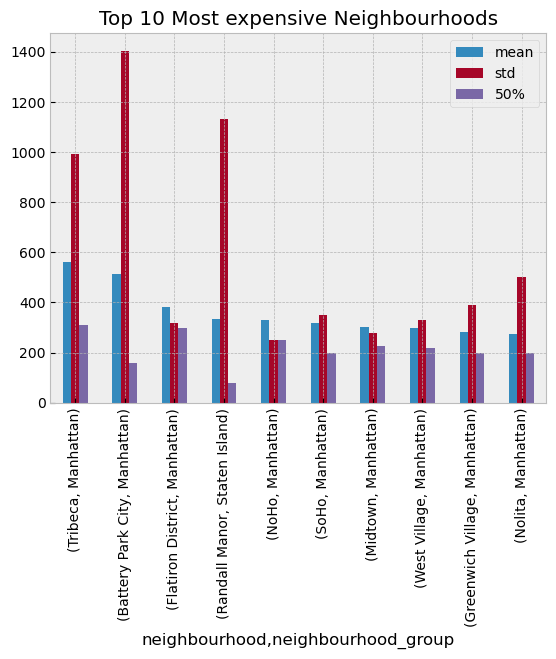

In [44]:
top10neigh.head(10)[['mean','std','50%']].plot(kind='bar',title='Top 10 Most expensive Neighbourhoods')

<Axes: title={'center': 'Top 10 Least expensive Neighbourhoods'}, xlabel='neighbourhood,neighbourhood_group'>

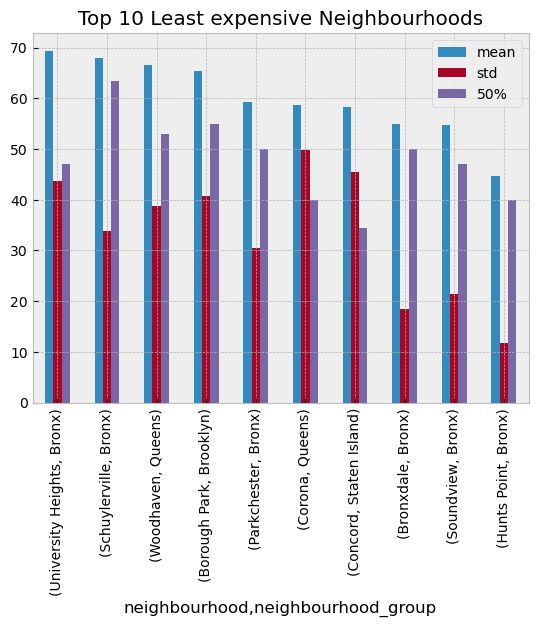

In [45]:
top10neigh.tail(10)[['mean','std','50%']].plot(kind='bar',title='Top 10 Least expensive Neighbourhoods')

### נבדוק מהם סוגי החדרים הכי נפוצים בכל רובע

In [46]:
new_df.groupby('neighbourhood_group')['room_type'].value_counts()

neighbourhood_group  room_type      
Bronx                Private room        545
                     Entire home/apt     317
                     Shared room          49
Brooklyn             Entire home/apt    6068
                     Private room       5874
                     Shared room         306
Manhattan            Entire home/apt    8438
                     Private room       4781
                     Shared room         336
Queens               Private room       2585
                     Entire home/apt    1550
                     Shared room         162
Staten Island        Private room        171
                     Entire home/apt     152
                     Shared room           8
Name: count, dtype: int64

Text(0.5, 1.0, 'Room Type By Neighbourhood group')

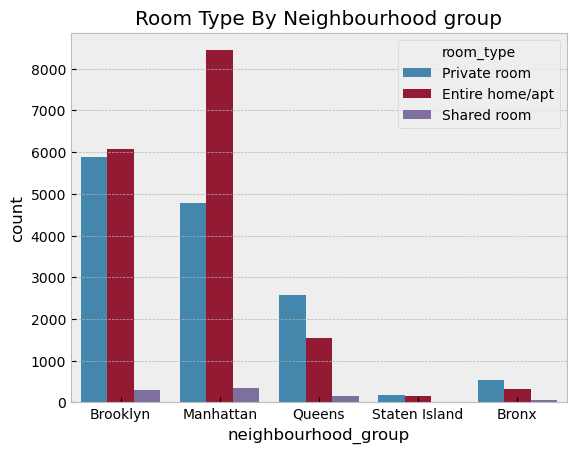

In [47]:
sns.countplot(data=new_df, x="neighbourhood_group",hue='room_type').set_title('Room Type By Neighbourhood group')

<Axes: title={'center': 'Minimum Nights By Neighbourhood Group'}, xlabel='neighbourhood_group', ylabel='Minimum Nights'>

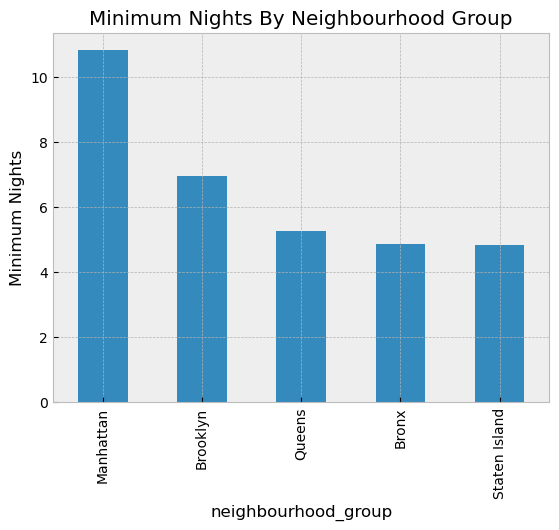

In [48]:
new_df.groupby('neighbourhood_group')['minimum_nights'].mean().sort_values(ascending=False).plot(kind='bar',ylabel='Minimum Nights',title='Minimum Nights By Neighbourhood Group')

<Axes: title={'center': 'Minimum Nights By Neighbourhood for a longstay'}, xlabel='neighbourhood', ylabel='Minimum Nights'>

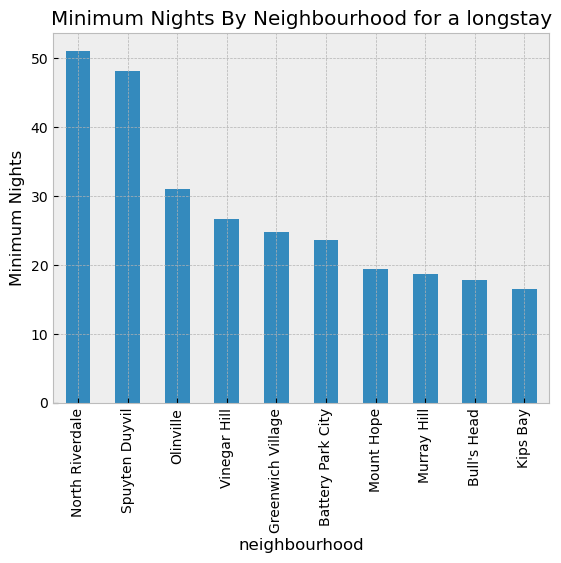

In [49]:
new_df.groupby('neighbourhood')['minimum_nights'].mean().sort_values(ascending=False).head(10).plot(kind='bar',ylabel='Minimum Nights',title='Minimum Nights By Neighbourhood for a longstay')

<Axes: title={'center': 'Minimum Nights By Neighbourhood for short stay'}, xlabel='neighbourhood', ylabel='Minimum Nights'>

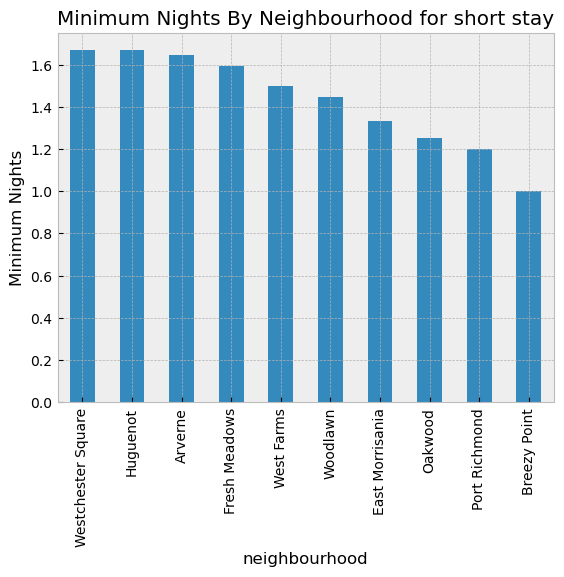

In [50]:
new_df.groupby('neighbourhood')['minimum_nights'].mean().sort_values(ascending=False).tail(10).plot(kind='bar',ylabel='Minimum Nights',title='Minimum Nights By Neighbourhood for short stay')

In [51]:
new_df.groupby(['name','neighbourhood'])['number_of_reviews'].count().reset_index(name='count').sort_values('count',ascending=False).head(10)

,name,neighbourhood,count
14340,Hillside Hotel,Jamaica,12
16683,Loft Suite @ The Box House Hotel,Greenpoint,11
3144,Artsy Private BR in Fort Greene Cumberland,Fort Greene,10
14339,Hillside Hotel,Briarwood,6
14991,IN MINT CONDITION-STUDIOS EAST 44TH/UNITED NAT...,Midtown,6
1929,A CLASSIC NYC NEIGHBORHOOD-EAST 86TH/5TH AVENUE,Upper East Side,5
29469,WEST VILLAGE Bohemian flat in neo-Tudor town h...,West Village,5
14070,Harlem Gem,Harlem,4
6152,Brooklyn Apartment,Bedford-Stuyvesant,4
16682,Loft Suite @ Box House Hotel,Greenpoint,4


### גרף שמציג את המחיר השוני במחירים לילה לפי מיקום גאוגפי

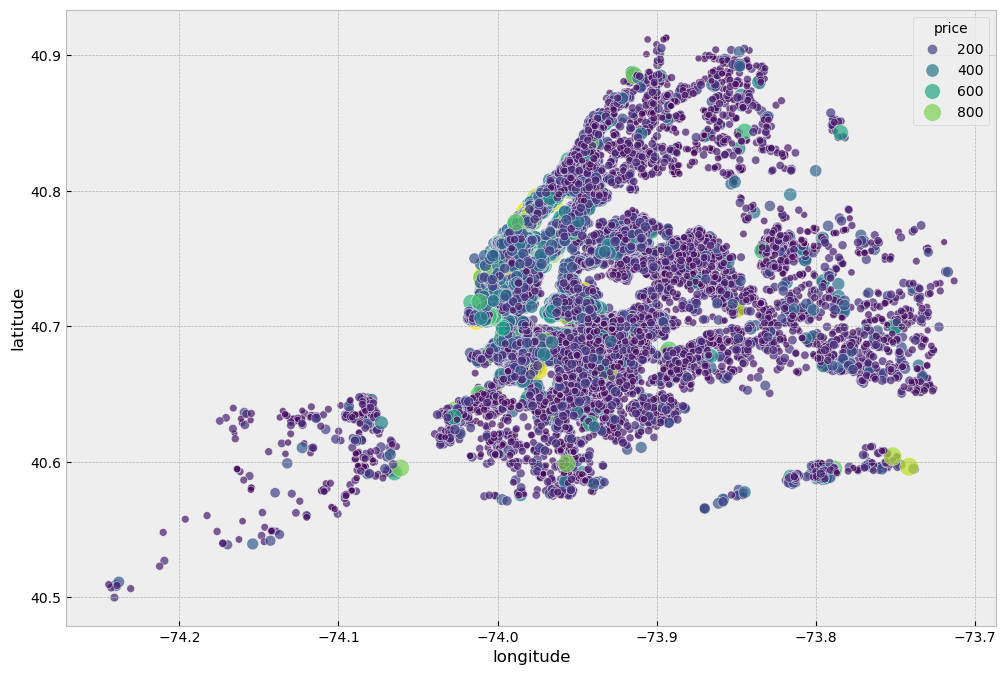

In [52]:
df_heatmap = new_df[new_df['price'] < 1000]  
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_heatmap,x='longitude',y='latitude',hue='price',palette='viridis',alpha=0.7,size='price',sizes=(20, 200))
plt.title='price'

#### בדיקת הקשר בין זמינות למחיר

<Axes: xlabel='availability_365', ylabel='price'>

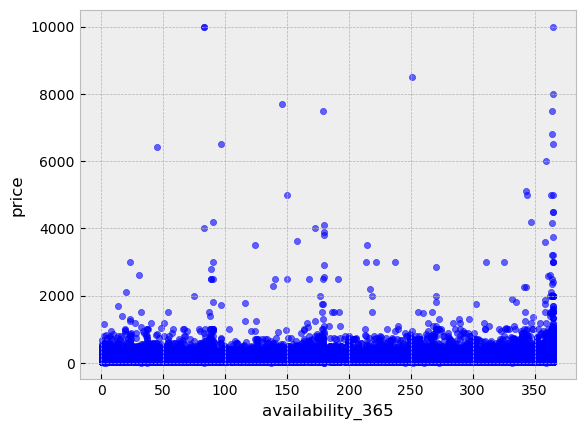

In [53]:

new_df.plot(kind='scatter',x='availability_365',y='price',alpha=0.6)

### הנקודות צפופות אין קשר ישיר בין זמינות למחיר

####   מי הם עשרת בעלי הנכסים הכי גדולים וכמה נכסים יש להם? 

<Axes: title={'center': 'Top 10 Bigges Hosts in NYC'}, xlabel='host_name'>

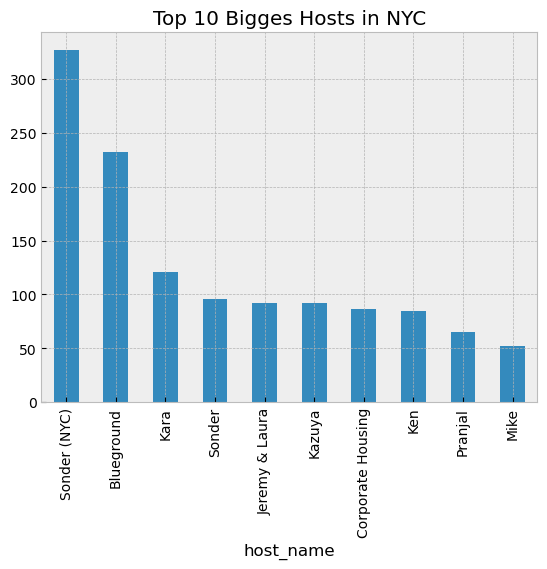

In [54]:
top10hosts=new_df[new_df['host_id'].isin(new_df['host_id'].value_counts().head(10).index)]
top10hosts['host_name'].value_counts().plot(kind='bar',title='Top 10 Bigges Hosts in NYC')

### איפה רוב הנכסים שלהם מפוזרים

In [55]:
top10hosts['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan    1169
Queens         70
Brooklyn        9
Name: count, dtype: int64

#### בעלי נכסים גדולים מחזיקים נכסים רק בשלושת הרובעים הגדולים הם לא משקיעים בברונקס ואי הפסל

#### בעלי נכסים גדולים מחזיקים את רוב הנכסים שלהם במנהטן

In [56]:
top10hosts.groupby('neighbourhood_group')['room_type'].value_counts()

neighbourhood_group  room_type      
Brooklyn             Private room          6
                     Entire home/apt       3
Manhattan            Entire home/apt    1146
                     Private room         23
Queens               Private room         70
Name: count, dtype: int64

#### רוב הנכסים שבעלי הנכסים הגדולים מחזיקים מבין כל הנכסים שהם מחזיקים הם דירות או בתים פרטיים במנהטן

<Axes: title={'center': 'The Average price By neghbourhood group of the Top 10 Biggest Hosts'}, xlabel='Neighbourhood Group', ylabel='Average price'>

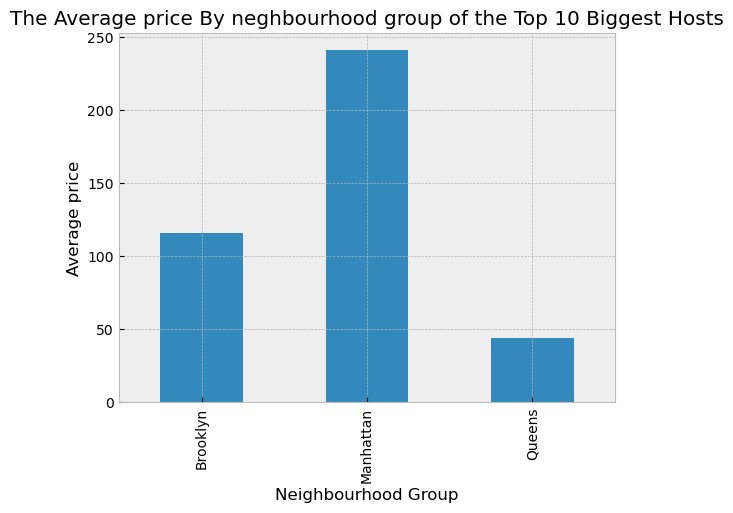

In [57]:
top10hosts.groupby('neighbourhood_group')['price'].mean().plot(kind='bar',ylabel='Average price',xlabel='Neighbourhood Group',title='The Average price By neghbourhood group of the Top 10 Biggest Hosts')

<Axes: xlabel='price', ylabel='number_of_reviews'>

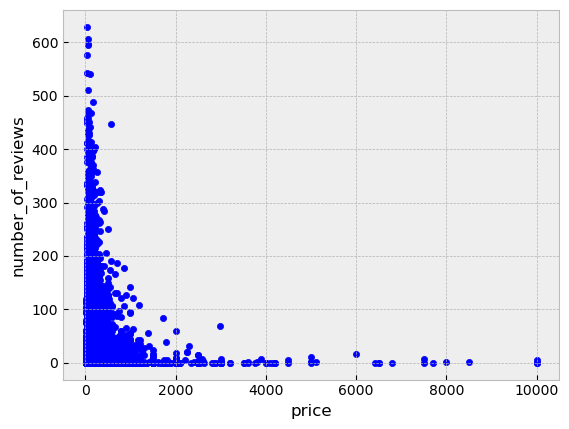

In [58]:
new_df.plot(kind='scatter',y='number_of_reviews', x='price')

In [59]:
new_df[new_df['number_of_reviews']>500]['price'].mean()

np.float64(54.25)

<Axes: xlabel='number_of_reviews', ylabel='reviews_per_month'>

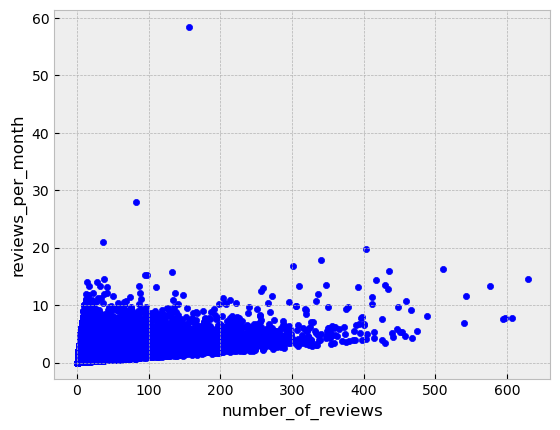

In [60]:
new_df.plot(kind='scatter',x='number_of_reviews', y='reviews_per_month')

### חלק 5

In [61]:
def check_popularity(x):
    if x<=3:
        return 'low popularity'
    elif 3<x<=30:
        return 'medium popularity'
    elif x>30:
        return 'high popularity'
    

In [62]:
new_df['popularity']=new_df['number_of_reviews'].apply(check_popularity)
new_df['popularity'].value_counts()

popularity
medium popularity    11492
low popularity       10532
high popularity       9318
Name: count, dtype: int64

In [63]:
def check_availability (x):
    if x<=80:
        return 'low availability'
    elif 80<x<=250:
        return 'medium availability'
    elif 250<x<=365:
        return 'high availability'

In [64]:
new_df['availability'] = new_df['availability_365'].apply(check_availability)
new_df['availability'].value_counts()

availability
high availability      10979
medium availability    10314
low availability       10049
Name: count, dtype: int64

In [65]:
def check_type_of_stay(x):
  if x<=1:
      return 'short stay'
  elif 1<x<=3:
       return 'meduim stay'
  elif x>3:
       return 'long stay'

In [66]:
new_df['stay_type']=new_df['minimum_nights'].apply(check_type_of_stay)
new_df['stay_type'].value_counts()

stay_type
meduim stay    12742
long stay      10862
short stay      7738
Name: count, dtype: int64

In [67]:
def convert_to_price_bucket(x):
    if x<=70:
        return 1
    elif 50<x<=112:
        return 2
    elif 112<x<=189:
        return 3
    else:
        return 4

In [68]:
new_df['price_bucket']=new_df['price'].apply(convert_to_price_bucket)
new_df['price_bucket'].value_counts()

price_bucket
1    8286
3    7867
4    7780
2    7409
Name: count, dtype: int64

In [69]:
def check_years_since_last_review(x):
    if x>0:
        return (2025-x)
    elif x<=0:
        return(15)

In [70]:
new_df['years_since_last_review']=new_df['year_of_last_review'].astype(int).apply(check_years_since_last_review)

In [71]:
new_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,year_of_last_review,popularity,availability,stay_type,price_bucket,years_since_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,...,2018-10-19,0.21,6,365,2018,medium popularity,high availability,short stay,3,7
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,...,2019-05-21,0.38,2,355,2019,high popularity,high availability,short stay,4,6
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,...,0,0.00,1,365,0,low popularity,high availability,meduim stay,3,15
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,...,2019-07-05,4.64,1,194,2019,high popularity,medium availability,short stay,2,6
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,...,2019-06-22,0.59,1,129,2019,high popularity,medium availability,meduim stay,4,6


In [72]:
new_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'year_of_last_review', 'popularity', 'availability',
       'stay_type', 'price_bucket', 'years_since_last_review'],
      dtype='object')

In [73]:
data=new_df[[ 'neighbourhood_group','latitude', 'longitude','room_type', 'availability_365','number_of_reviews','price_bucket','minimum_nights',
        'calculated_host_listings_count','availability', 'popularity','stay_type','years_since_last_review']].copy()



In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31342 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             31342 non-null  object 
 1   latitude                        31342 non-null  float64
 2   longitude                       31342 non-null  float64
 3   room_type                       31342 non-null  object 
 4   availability_365                31342 non-null  int64  
 5   number_of_reviews               31342 non-null  int64  
 6   price_bucket                    31342 non-null  int64  
 7   minimum_nights                  31342 non-null  int64  
 8   calculated_host_listings_count  31342 non-null  int64  
 9   availability                    31342 non-null  object 
 10  popularity                      31342 non-null  object 
 11  stay_type                       31342 non-null  object 
 12  years_since_last_review         31342

In [75]:
dummy_df=pd.get_dummies(data)

In [76]:
dummy_df.shape

(31342, 25)

In [77]:
dummy_df

,latitude,longitude,availability_365,number_of_reviews,price_bucket,minimum_nights,calculated_host_listings_count,years_since_last_review,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,...,room_type_Shared room,availability_high availability,availability_low availability,availability_medium availability,popularity_high popularity,popularity_low popularity,popularity_medium popularity,stay_type_long stay,stay_type_meduim stay,stay_type_short stay
0,40.64749,-73.97237,365,9,3,1,6,7,False,True,...,False,True,False,False,False,False,True,False,False,True
1,40.75362,-73.98377,355,45,4,1,2,6,False,False,...,False,True,False,False,True,False,False,False,False,True
2,40.80902,-73.94190,365,0,3,3,1,15,False,False,...,False,True,False,False,False,True,False,False,True,False
3,40.68514,-73.95976,194,270,2,1,1,6,False,True,...,False,False,False,True,True,False,False,False,False,True
5,40.74767,-73.97500,129,74,4,3,1,6,False,False,...,False,False,False,True,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40.67853,-73.94995,9,0,1,2,2,15,False,True,...,False,False,True,False,False,True,False,False,True,False
48891,40.70184,-73.93317,36,0,1,4,2,15,False,True,...,False,False,True,False,False,True,False,True,False,False
48892,40.81475,-73.94867,27,0,3,10,1,15,False,False,...,False,False,True,False,False,True,False,True,False,False
48893,40.75751,-73.99112,2,0,1,1,6,15,False,False,...,True,False,True,False,False,True,False,False,False,True


In [78]:
scaler = MinMaxScaler()

In [79]:
normalize_data = pd.DataFrame(scaler.fit_transform(dummy_df), columns=dummy_df.columns)
normalize_data

,latitude,longitude,availability_365,number_of_reviews,price_bucket,minimum_nights,calculated_host_listings_count,years_since_last_review,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,...,room_type_Shared room,availability_high availability,availability_low availability,availability_medium availability,popularity_high popularity,popularity_low popularity,popularity_medium popularity,stay_type_long stay,stay_type_meduim stay,stay_type_short stay
0,0.357393,0.511921,1.000000,0.014308,0.666667,0.000000,0.015337,0.111111,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.614199,0.490469,0.972527,0.071542,1.000000,0.000000,0.003067,0.000000,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.748252,0.569257,1.000000,0.000000,0.666667,0.001601,0.000000,1.000000,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.448496,0.535649,0.530220,0.429253,0.333333,0.000000,0.000000,0.000000,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.599802,0.506972,0.351648,0.117647,1.000000,0.001601,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31337,0.432502,0.554109,0.021978,0.000000,0.000000,0.000801,0.003067,1.000000,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31338,0.488906,0.585684,0.096154,0.000000,0.000000,0.002402,0.003067,1.000000,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
31339,0.762117,0.556517,0.071429,0.000000,0.666667,0.007206,0.000000,1.000000,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
31340,0.623612,0.476639,0.002747,0.000000,0.000000,0.000000,0.015337,1.000000,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [80]:
def get_kmeans_accuracy(data, top_k):
    sum_squared = []
    silhouette = []
    K = range(2, top_k + 1)
    for i in K:
        kmeans = KMeans(n_clusters = i)
        kmeans.fit(data)
        sum_squared.append(kmeans.inertia_) # errors
        silhouette.append(silhouette_score(data, kmeans.labels_))
    return pd.DataFrame({
    "K": K,
    "SSE": sum_squared,
    "SIL": silhouette
  })

In [116]:
result = get_kmeans_accuracy(normalize_data, 10) 
result

,K,SSE,SIL
0,2,95036.896375,0.157736
1,3,87361.738787,0.132890
2,4,82070.343406,0.138201
3,5,77891.735873,0.138603
4,6,70279.329860,0.183864
5,7,69392.017576,0.161517
6,8,64562.314172,0.175153
7,9,64412.777803,0.164175
8,10,61263.275593,0.165228


In [117]:
result.set_index("K", inplace=True)
result

,SSE,SIL
K,,
2,95036.896375,0.157736
3,87361.738787,0.132890
4,82070.343406,0.138201
5,77891.735873,0.138603
6,70279.329860,0.183864
7,69392.017576,0.161517
8,64562.314172,0.175153
9,64412.777803,0.164175
10,61263.275593,0.165228


<Axes: xlabel='K'>

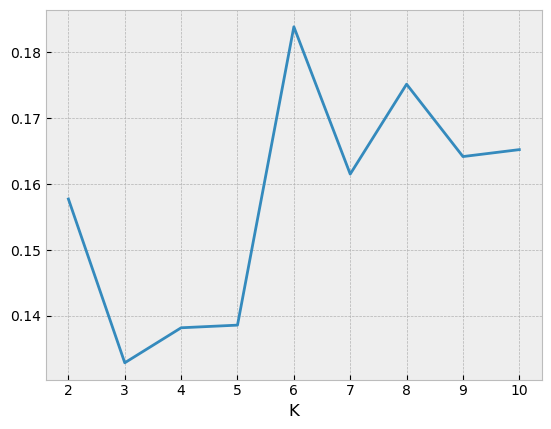

In [119]:
result["SIL"].plot()

In [136]:
kmeans_obj = KMeans(n_clusters = 6)
kmeans_obj.fit(normalize_data)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [137]:
new_df["Cluster"] = kmeans_obj.labels_
new_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,reviews_per_month,calculated_host_listings_count,availability_365,year_of_last_review,popularity,availability,stay_type,price_bucket,years_since_last_review,Cluster
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,...,0.21,6,365,2018,medium popularity,high availability,short stay,3,7,2
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,...,0.38,2,355,2019,high popularity,high availability,short stay,4,6,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,...,0.00,1,365,0,low popularity,high availability,meduim stay,3,15,2
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,...,4.64,1,194,2019,high popularity,medium availability,short stay,2,6,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,...,0.59,1,129,2019,high popularity,medium availability,meduim stay,4,6,0


In [138]:
new_df['Cluster'].value_counts()

Cluster
2    6485
4    5759
0    5424
3    4890
1    4494
5    4290
Name: count, dtype: int64

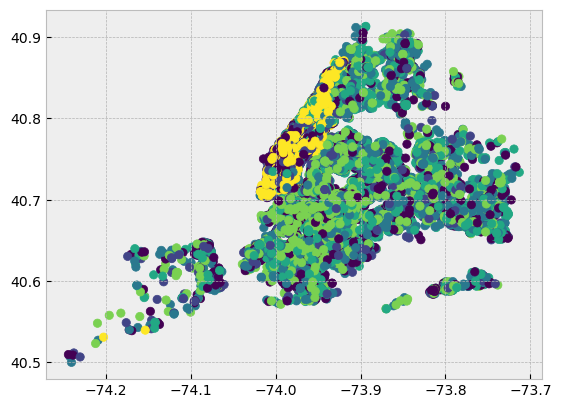

In [139]:
plt.scatter(new_df['longitude'], new_df['latitude'], c=kmeans_obj.labels_, cmap='viridis')

<Axes: xlabel='Cluster', ylabel='count'>

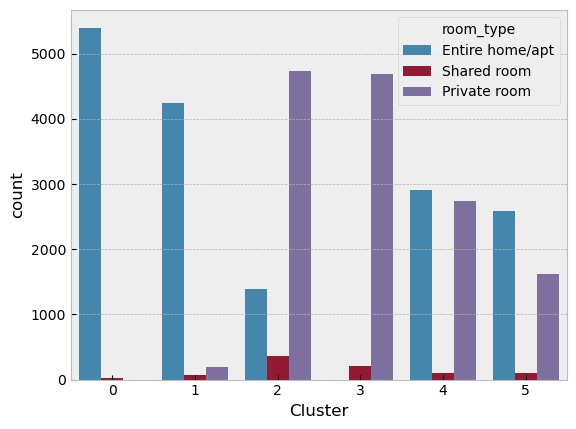

In [140]:
sns.countplot(data=new_df, x="Cluster",hue='room_type')

<Axes: xlabel='Cluster', ylabel='count'>

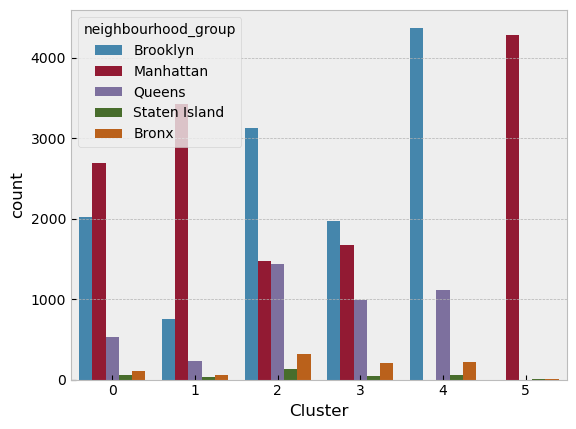

In [141]:
sns.countplot(data=new_df, x="Cluster",hue='neighbourhood_group')

<Axes: xlabel='Cluster', ylabel='count'>

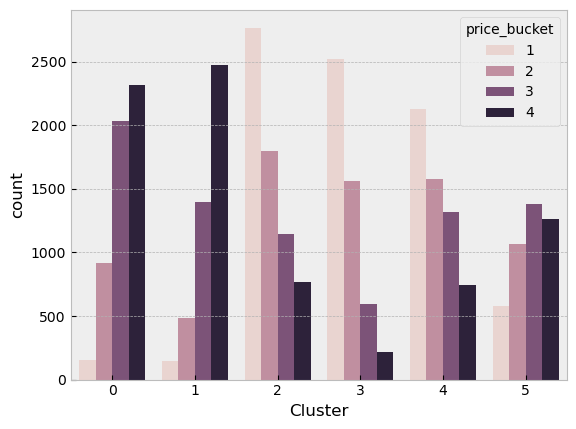

In [142]:
sns.countplot(data=new_df, x="Cluster",hue='price_bucket')

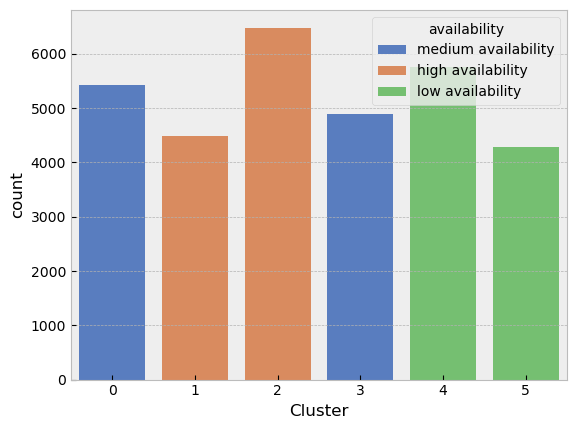

In [143]:
sns.countplot(data=new_df, x='Cluster', hue='availability', palette='muted')
plt.show()


<Axes: xlabel='Cluster', ylabel='count'>

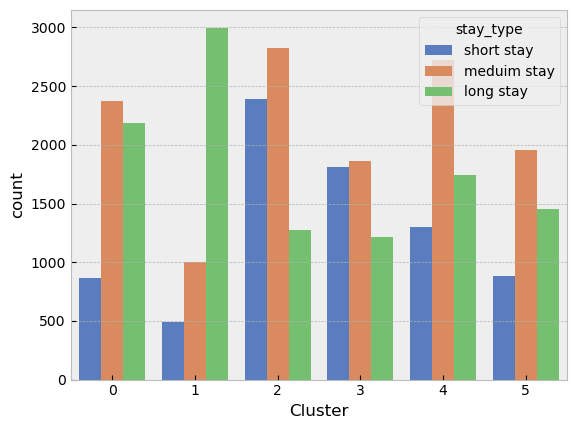

In [144]:
sns.countplot(data=new_df, x='Cluster', hue='stay_type', palette='muted')


In [146]:
x=normalize_data.drop(columns=['price_bucket'])
y= new_df['price_bucket']

In [147]:
x.head()

,latitude,longitude,availability_365,number_of_reviews,minimum_nights,calculated_host_listings_count,years_since_last_review,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,room_type_Shared room,availability_high availability,availability_low availability,availability_medium availability,popularity_high popularity,popularity_low popularity,popularity_medium popularity,stay_type_long stay,stay_type_meduim stay,stay_type_short stay
0,0.357393,0.511921,1.000000,0.014308,0.000000,0.015337,0.111111,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.614199,0.490469,0.972527,0.071542,0.000000,0.003067,0.000000,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.748252,0.569257,1.000000,0.000000,0.001601,0.000000,1.000000,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.448496,0.535649,0.530220,0.429253,0.000000,0.000000,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.599802,0.506972,0.351648,0.117647,0.001601,0.000000,0.000000,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [148]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25)

In [149]:
Rf = RandomForestClassifier(n_estimators = 400)
Rf.fit(x_train,y_train)
Rf_pred = Rf.predict(x_test)
metrics.confusion_matrix(y_test,Rf_pred)

array([[1668,  314,   68,   16],
       [ 517,  783,  464,  134],
       [ 117,  344,  930,  563],
       [  39,  119,  494, 1266]])

In [150]:
metrics.accuracy_score(y_test,Rf_pred)

0.5930321592649311

<Axes: >

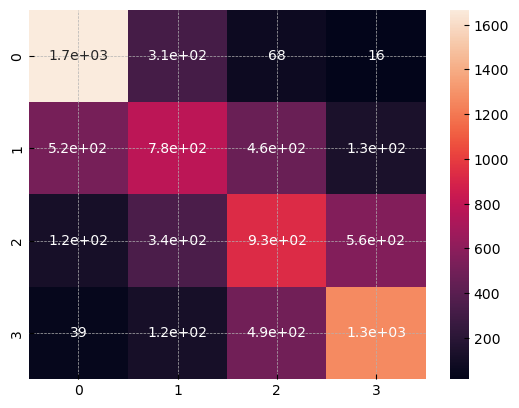

In [151]:
sns.heatmap(metrics.confusion_matrix(y_test,Rf_pred), annot=True)

In [152]:
# נניח ש-Rf הוא מודל RandomForestClassifier מאומן
importances = Rf.feature_importances_

# אפשר להציג אותם כמו שעשינו לפני כן
feat_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_importance_df


,Feature,Importance
1,longitude,0.180784
0,latitude,0.170849
2,availability_365,0.134940
3,number_of_reviews,0.099679
12,room_type_Entire home/apt,0.087669
5,calculated_host_listings_count,0.062936
13,room_type_Private room,0.062747
4,minimum_nights,0.053314
6,years_since_last_review,0.025860
9,neighbourhood_group_Manhattan,0.021227
